# Comparación de Gini y Entropía 

**Almacenes y Minería de Datos — Facultad de Ciencias, UNAM**

## Paso 4: Síntesis

Elegimos la misma variable categórica usada en el notebook de heterogeneidad
(`nivel_escolaridad`) y calculamos sobre ella **tanto** la entropía de Shannon
**como** una versión del coeficiente de Gini aplicada a las frecuencias de sus
categorías, para comparar explícitamente ambas lecturas del mismo fenómeno.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import polars as pl
from config.rutas import RUTA_DATA_PROCESSED, ARCHIVO_ENDIREH_LIMPIO, RUTA_REPORTS_FIGURES
from src.models.heterogeneidad import calcular_entropia_shannon
from src.models.concentracion import calcular_gini
from src.visualization.graficas import graficar_curva_lorenz

df = pl.read_csv(RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_LIMPIO)

conteo = df["nivel_escolaridad"].value_counts().sort("nivel_escolaridad")
frecuencias = conteo["count"].to_numpy()
conteo

nivel_escolaridad,count
str,u32
"""A1""",61977
"""A2""",2399
"""B1""",12597
"""B2""",9549
"""C1""",14458
"""C2""",4773


In [2]:
shannon = calcular_entropia_shannon(df, "nivel_escolaridad")

gini_escolaridad = calcular_gini(frecuencias)

print(f"Entropía de Shannon (H):     {shannon['H']:.4f} / {shannon['H_max']:.4f} bits "
      f"(uniformidad relativa: {shannon['uniformidad_relativa']:.4f})")
print(f"Gini sobre las frecuencias:  {gini_escolaridad:.4f}")


Entropía de Shannon (H):     1.8488 / 2.5850 bits (uniformidad relativa: 0.7152)
Gini sobre las frecuencias:  0.5201


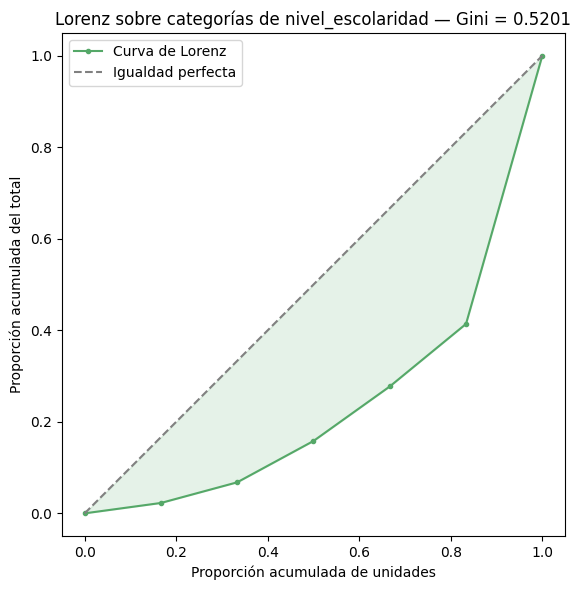

In [3]:
fig = graficar_curva_lorenz(
    frecuencias, gini_escolaridad,
    titulo="Lorenz sobre categorías de nivel_escolaridad",
    color="#55A868",
    ruta_salida=str(RUTA_REPORTS_FIGURES / "gini_vs_entropia_escolaridad.png"),
)

### Diferencia conceptual entre ambos índices 


Al analizar la variable `nivel_escolaridad`, podemos ver que la **Entropía de Shannon** es de **1.8488 bits**, con una uniformidad relativa del **71.52%**. Esto indica que existe cierta diversidad entre los diferentes niveles de escolaridad y que los datos no están completamente concentrados en una sola categoría.

Por otro lado, el **Coeficiente de Gini** es de **0.5201**, lo que muestra que sí existe una concentración importante. Esto se debe principalmente a la categoría **A1**, que es la más frecuente y cuenta con **61,977 registros**.

Por lo tanto, ambos indicadores no se contradicen, sino que muestran aspectos diferentes de los datos: la **entropía** nos habla de la diversidad de las categorías, mientras que el **Gini** permite observar qué tan concentrados están los registros en unas pocas categorías. En este caso, aunque existe diversidad, la categoría A1 tiene un peso mucho mayor que las demás.